# <p><center style="font-family:newtimeroman;font-size:180%;">Generative AI Chatbot for Alzheimer Disease</center></p>
# <p><center style="font-family:newtimeroman;font-size:180%;">Leader</center></p>
## Steps:

| Step |Description                                     |
|------|------------------------------------------------|
|0|[Introduction](#0)|
| 1    |[Import Libraries](#1)                          |
| 2    |[Read Data](#2)                                 |    
|3   |[Data Spliting](#3)|
|4|[Perform Text Vectorization With TensorFlow](#4)|
|5|[Positional Embedding](#5)|
|6|[Causal Masking](#6)|
|7|[Scaled Dot-Product Attention](#7)|
|8|[Multi-Head Attention](#8)|
|9|[The Encoder](#9)|
|10|[The Docoder](#10)|
|11|[The Transformer Block for Encoder and Docoder](#11)||
|12|[Training the Transformer](#12)|
|13|[Evaluation the Transformer](#13)|
|14|[Saving Tokenizer for Source and Target](#14)|
|15|[Testing the Transformer](#15)|
|16|[Reference](#16)|

**<a id="0"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Introduction </p>
<a class="btn" href="#home">Tabel of Contents</a>

#### Generative AI Chatbot for Alzheimer Disease
This notebook builds a basic Encoder-Decoder variant of the Transformer architecture from scratch (Multi-Head Attention, Scaled Dot-Product Attention and Causal Masking included) in TensorFlow.

It serves to understand how each part of the Transformer works and how they all fit together.

The Transformer is then tested on a simple seq2seq task : Generative AI Chatbot for Alzheimer Disease.

[<img src="https://ar5iv.labs.arxiv.org/html/1706.03762/assets/Figures/ModalNet-21.png" width="300">](https://arxiv.org/abs/1706.03762)

what is the difference between Transformers and RNNs?

Convolutional Neural Networks (CNNs) are primarily used for image and video-related tasks. They excel at capturing spatial relationships and extracting features from input data. CNNs consist of convolutional layers, pooling layers, and fully connected layers. Convolutional layers use filters to scan and convolve the input data, capturing local patterns and features. Pooling layers shrink the size of the data while keeping the most essential details intact. Fully connected layers provide the final classification or regression outputs.

Recurrent Neural Networks (RNNs) are designed for sequential data, such as text or time series. They process input data sequentially, maintaining hidden states that retain information from previous inputs. RNNs are like a brain that remembers past information, which makes them useful for tasks where understanding context is essential, like language processing, understanding speech, and translating languages. However, RNNs suffer from vanishing or exploding gradient problems, limiting their ability to capture long-term dependencies.

Transformers are a relatively new architecture that gained significant popularity, especially in the field of NLP. Vaswani et al. introduced them in the paper "Attention Is All You Need" in 2017. Transformers rely on self-attention mechanisms to capture global dependencies between input elements. They can process inputs in parallel, making them highly parallelizable and efficient for training on modern hardware. Transformers have achieved state-of-the-art results in various NLP tasks, including language translation, text summarization, and sentiment analysis.

 Compared to CNNs and RNNs, Transformers have several advantages:¶

Parallelization: Transformers can process input elements in parallel, making them faster to train and more efficient on hardware that supports parallel operations.

Attention mechanism: Transformers use self-attention to capture global dependencies in the input sequence, allowing them to attend to relevant context across the entire sequence. This is particularly useful in NLP tasks where long-range dependencies are essential.

No sequential processing: Unlike RNNs, Transformers do not process input sequentially. They can take advantage of parallel processing and are not limited by the sequential nature of RNNs, enabling faster training and inference.


**<a id="1"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Import Libraries </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [1]:
import os
import pandas as pd
import random
import matplotlib.pyplot as plt
import tensorflow as tf
import string
import re
import numpy as np

2024-03-11 12:18:28.001615: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-11 12:18:28.001709: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-11 12:18:28.120114: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
print(f"Tensor Flow Version: {tf.__version__}")
print()
gpu = len(tf.config.list_physical_devices('GPU'))>0
print("GPU is", "AVAILABLE" if gpu else "NOT AVAILABLE")

Tensor Flow Version: 2.15.0

GPU is AVAILABLE


**<a id="2"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Read Data </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [3]:
df=pd.read_csv('/kaggle/input/alzhimer-chat-leader/full_Chat_data.csv',usecols=[1,2])
df.columns=['source','target']
df=df.astype(str)
# display a few random samples
df.sample(5)

,source,target
13146,Are there any professional services available ...,"Yes, professional services such as home health..."
19484,Are there specific dietary recommendations to ...,"A balanced diet rich in fruits, vegetables, wh..."
4670,How might the potential cognitive benefits of ...,The potential cognitive benefits of coconut oi...
22432,How do beta-secretase and gamma-secretase enzy...,Beta-secretase and gamma-secretase enzymes cle...
23751,How does heart failure impact the development ...,Heart failure affects the pumping function of ...


In [4]:
df.shape

(25177, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25177 entries, 0 to 25176
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   source  25177 non-null  object
 1   target  25177 non-null  object
dtypes: object(2)
memory usage: 393.5+ KB


**<a id="3"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Data Spliting </p>
<a class="btn" href="#home">Tabel of Contents</a>

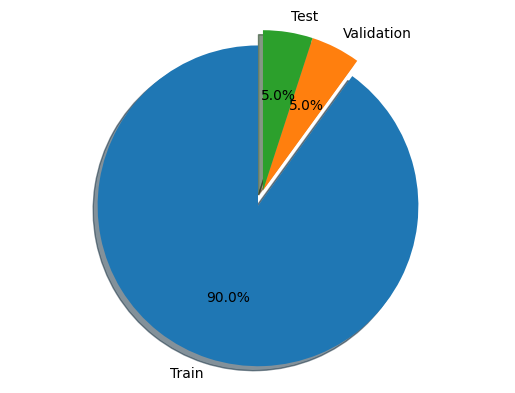

In [6]:
# shuffle the data
df = df.sample(frac=1).reset_index(drop=True)

# split the data into train, validation, and test sets
train_size = int(len(df) * 0.9)
val_size = int(len(df) * 0.05)
test_size = int(len(df) * 0.05)

train_df = df[:train_size]
val_df = df[train_size:train_size+val_size]
test_df = df[train_size+val_size:]

# display the data sets representations using a pie chart just to see the distribution of the data
labels = 'Train', 'Validation', 'Test'
sizes = [len(train_df), len(val_df), len(test_df)]
explode = (0.1, 0, 0)
fig1, ax1 = plt.subplots()
ax1.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%', shadow=True, startangle=90)
ax1.axis('equal')
plt.show()


**<a id="4"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Perform Text Vectorization With TensorFlow </p>
<a class="btn" href="#home">Tabel of Contents</a>

First, we need to parse our raw text data and vectorize it.

To keep things simple, we will first limit our vocabulary using the **max_tokens** parameter. We will also limit the length of each sentence using the **sequence_length** parameter.

Each sentence will be standardized, tokenized by word, and then indexed by token.

This will result in a batch of vectors of tokens, stored in a **2D** matrix of shape [(batch_size, **sequence_length**)].

In [7]:
max_tokens = 25000
sequence_length = 200

# define a custom standardization function that convert to lowercase and strips all punctuations except "[" and "]" (so we can tell apart "start" from "[start]").
strip_chars = string.punctuation
strip_chars = strip_chars.replace("[", "")
strip_chars = strip_chars.replace("]", "")
 
def custom_standardization(input_string):
    lowercase = tf.strings.lower(input_string)
    return tf.strings.regex_replace(
        lowercase, f"[{re.escape(strip_chars)}]", "")

# tokenize the data using our custom standardization function
source_vectorization = tf.keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length,
)
target_vectorization = tf.keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length + 1, # add +1 token to our target sentences since they'll be shifted right by 1 during training
    standardize=custom_standardization,
)

# index all tokens in the source and target sentences
train_source_texts = train_df['source'].values
train_target_texts = train_df['target'].values
source_vectorization.adapt(train_source_texts)
target_vectorization.adapt(train_target_texts)

In [8]:
# display a random sample before and after vectorization just to test the vectorization
random_sample = random.randint(0, len(train_df))
print("Source texts (one random sample):", train_source_texts[random_sample]+' Leader')
print("Target texts (one random sample):", train_target_texts[random_sample]+' Leader')
print("Source vectors (one random sample):", source_vectorization(train_source_texts[random_sample]+' Leader'))
print("Target vectors (one random sample):", target_vectorization(train_target_texts[random_sample]+' Leader'))

# display the decoding of the vectorized text (from vector back to text) just to test the vectorization
source_decoded_text = ''
for i in range(len(source_vectorization(train_source_texts[random_sample]+' Leader'))):
    source_decoded_text += source_vectorization.get_vocabulary()[source_vectorization(train_source_texts[random_sample]+' Leader')[i]] + ' '
print("Source decoded texts (one random sample):", source_decoded_text)

target_decoded_text = ''
for i in range(len(target_vectorization(train_target_texts[random_sample]))):
    target_decoded_text += target_vectorization.get_vocabulary()[target_vectorization(train_target_texts[random_sample])[i]] + ' '
print("Target decoded texts (one random sample):", target_decoded_text)

Source texts (one random sample): What is the role of inflammation in Alzheimer's-related psychiatric symptoms? Leader
Target texts (one random sample): Inflammation may contribute to psychiatric symptoms in Alzheimer's, such as mood changes and agitation; addressing inflammation as part of a comprehensive care plan is important for managing these symptoms. Leader
Source vectors (one random sample): tf.Tensor(
[  12   17    3   28    5  179    4  145 1131   62    1    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0   

In [9]:
# display the shape of our vectorized data
train_source_vectors = source_vectorization(train_source_texts)
train_target_vectors = target_vectorization(train_target_texts)
print("Source vectors (shape):", train_source_vectors.shape)
print("Target vectors (shape):", train_target_vectors.shape)

Source vectors (shape): (22659, 200)
Target vectors (shape): (22659, 201)


**<a id="5"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Positional Embedding </p>
<a class="btn" href="#home">Tabel of Contents</a>

In order for our Transformer to be aware of the word order in each sentence, we must add some positional information to the data. **Words must become position-aware.**

First, each token in our vectors will be embedded in a low-dimensional vector (the dimensionality of the embedding space is defined by the **embedding_size** parameter).

Secondly, position information (info on where each word stands in the sentence) will be created and added to the embeddings.

This will result in a batch of vectors of positional embeddings, stored in a **3D** matrix of shape [(batch_size, sequence_length, **embedding_size**)].

In [10]:
class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, sequence_length, input_dim, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings = tf.keras.layers.Embedding(input_dim=input_dim, output_dim=output_dim) # token embedding layer
        self.position_embeddings = tf.keras.layers.Embedding(input_dim=sequence_length, output_dim=output_dim) # position embedding layer
        self.sequence_length = sequence_length
        self.input_dim = input_dim
        self.output_dim = output_dim

    def call(self, inputs):
        embedded_tokens = self.token_embeddings(inputs) # embed the tokens
        length = tf.shape(inputs)[-1]
        positions = tf.range(start=0, limit=length, delta=1) # create the positional information
        embedded_positions = self.position_embeddings(positions) # embed the positions 
        return embedded_tokens + embedded_positions # add the token and position embeddings to create the positional embeddings

    def compute_mask(self, inputs, mask=None):
        return tf.math.not_equal(inputs, 0)

    def get_config(self):
        config = super(PositionalEmbedding, self).get_config()
        config.update({
            "input_dim": self.input_dim,
            "output_dim": self.output_dim,
            "sequence_length": self.sequence_length,
        })
        return config

In [11]:
# display a random sample before and after embbeding just to test our class

embed_dim = 128

train_source_embedded = PositionalEmbedding(
    sequence_length=sequence_length,
    input_dim=max_tokens,
    output_dim=embed_dim,
    name="source_embedding",
) (train_source_vectors)

train_target_embedded = PositionalEmbedding(
    sequence_length=sequence_length,
    input_dim=max_tokens,
    output_dim=embed_dim,
    name="target_embedding",
) (train_source_vectors)

random_sample = random.randint(0, len(train_df))
print("Source texts (one random sample):", train_source_texts[random_sample])
print("Target texts (one random sample):", train_target_texts[random_sample])
print("Source vectors (one random sample):", source_vectorization(train_source_texts[random_sample]))
print("Target vectors (one random sample):", target_vectorization(train_target_texts[random_sample]))
print("Source embedded vectors (one random sample):", train_source_embedded[random_sample])
print("Target embedded vectors (one random sample):", train_target_embedded[random_sample])

Source texts (one random sample): tasks or work?
Target texts (one random sample): nan
Source vectors (one random sample): tf.Tensor(
[310  26 272   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0], shape=(200,), dtype=int64)
Target vectors (one rando

In [12]:
# display the shape of our embedded data just to test the class
print("Source embedded vectors (shape):", train_source_embedded.shape)
print("Target embedded vectors (shape):", train_target_embedded.shape)

Source embedded vectors (shape): (22659, 200, 128)
Target embedded vectors (shape): (22659, 200, 128)


<div style="color:#000; display:fill; border-radius:8px; background-color:#000; font-size:125%;">
    <p style="padding: 8px 12px 8px 12px; color:#fff;"><b>The Attention mechanism</b></p>
</div>

The goal here is to make each of our words (positional embeddings at this point) aware of the other words surrounding them. **Words must become context-aware.**

The implementation of the Attention mechanism involves the following 3 steps : 

- Causal Masking
- Scaled Dot-Product Attention
- Multi-Head Attention

In practice, we could just use **tf.keras.layers.MultiHeadAttention** instead of building it from scratch, but let's do it anyway! 😒

**<a id="6"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Causal Masking </p>
<a class="btn" href="#home">Tabel of Contents</a>


Since our words will now be context-aware (aware of words before **and** after them in the sentence), we need a way to mask those *after-words* when needed be (i.e. during training).

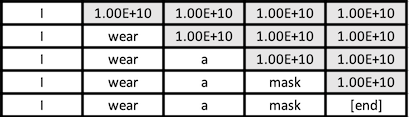

In [13]:
# credits to OpenAI for that one (https://github.com/openai/gpt-2/blob/master/src/model.py)

def shape_list(x):
    """Deal with dynamic shape in tensorflow cleanly."""
    static = x.shape.as_list()
    dynamic = tf.shape(x)
    return [dynamic[i] if s is None else s for i, s in enumerate(static)]

def attention_mask(nd, ns, *, dtype):
    """1's in the lower triangle, counting from the lower right corner.
    Same as tf.matrix_band_part(tf.ones([nd, ns]), -1, ns-nd), but doesn't produce garbage on TPUs.
    """
    i = tf.range(nd)[:,None]
    j = tf.range(ns)
    m = i >= j - ns + nd
    return tf.cast(m, dtype)

def mask_attn_weights(w):
    # w has shape [batch, heads, dst_sequence, src_sequence], where information flows from src to dst.
    _, _, nd, ns = shape_list(w)
    b = attention_mask(nd, ns, dtype=w.dtype)
    b = tf.reshape(b, [1, 1, nd, ns])
    w = w*b - tf.cast(1e10, w.dtype)*(1-b)
    return w

In [14]:
# display the causal masking of a random tensor just to test the function
random_tensor = tf.random.uniform(shape=(1, 1, 5, 5), minval=0, maxval=1, dtype=tf.float32)
print("Masked attention weights:", mask_attn_weights(random_tensor))

Masked attention weights: tf.Tensor(
[[[[ 1.5895605e-02 -1.0000000e+10 -1.0000000e+10 -1.0000000e+10
    -1.0000000e+10]
   [ 4.0102589e-01  5.2423191e-01 -1.0000000e+10 -1.0000000e+10
    -1.0000000e+10]
   [ 8.2561028e-01  7.1944344e-01  1.4354694e-01 -1.0000000e+10
    -1.0000000e+10]
   [ 5.4311645e-01  6.3608766e-02  1.4713812e-01  8.1237316e-02
    -1.0000000e+10]
   [ 4.0125215e-01  9.2968214e-01  9.0757883e-01  9.2826700e-01
     8.4118211e-01]]]], shape=(1, 1, 5, 5), dtype=float32)


**<a id="7"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Scaled Dot-Product Attention </p>
<a class="btn" href="#home">Tabel of Contents</a>

This function is what makes our words context-aware.

We want to compare each word with every other words around them and take note of how *related* they are. Technically, this process can be described as "mapping a query and a set of key-value pairs to an output". It can be summarized as follows :
- We take a **Q**uery of elements.
- For each element in the **Q**uery, we score how much that element is related to every **K**ey (This is done using a compatibility function : MatMul). If needed be, Causal Masking will be applied here.
- Then, we use these relationship scores to weight a sum of **V**alues, which will be our new context-aware representations.

[<img src="https://ar5iv.labs.arxiv.org/html/1706.03762/assets/Figures/ModalNet-19.png" width="120">](https://arxiv.org/abs/1706.03762)

In [15]:
def scaled_dot_product_attention(q, k, v, use_causal_mask=False):
    d_k = tf.cast(tf.shape(k)[-1], tf.float32)
    scores = tf.matmul(q, k, transpose_b=True) # Matmul of Q and K
    scaled_scores = scores / tf.math.sqrt(d_k) # Scale
    if use_causal_mask:
        scaled_scores = mask_attn_weights(scaled_scores) # Mask (opt.)
    weights = tf.nn.softmax(scaled_scores, axis=-1) # SoftMax
    output = tf.matmul(weights, v) # Matmul of SoftMax and V
    return output

In [16]:
# display the shape of our attention output just to test the function
input = train_source_embedded[:1000]
input = tf.expand_dims(input, axis=1)
print("Scaled dot product attention (shape):", scaled_dot_product_attention(input, input, input, use_causal_mask=True).shape)

Scaled dot product attention (shape): (1000, 1, 200, 128)


**<a id="8"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Multi-Head Attention </p>
<a class="btn" href="#home">Tabel of Contents</a>

Multi-head attention was introduced in [Attention is all you need](https://arxiv.org/abs/1706.03762) and is wayyy to technical for me to try and explain here. But basically, it allows for multiple Scaled Dot-Production Attention functions to be run in parallel. 😅
    
[<img src="https://ar5iv.labs.arxiv.org/html/1706.03762/assets/Figures/ModalNet-20.png" width="200">](https://arxiv.org/abs/1706.03762)

In [17]:
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, embed_dim, h, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.h = h
        if embed_dim % h != 0:
            raise ValueError(
                f"dimension of the embedding space = {embed_dim} should be divisible by number of heads = {h}"
            )
        self.q_linear = tf.keras.layers.Dense(embed_dim)
        self.k_linear = tf.keras.layers.Dense(embed_dim)
        self.v_linear = tf.keras.layers.Dense(embed_dim)
        self.concat_linear = tf.keras.layers.Dense(embed_dim)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, shape=(batch_size, -1, self.h, self.embed_dim // self.h))
        return tf.transpose(x, perm=[0, 2, 1, 3])
    
    def concat_heads(self, x, batch_size):
        x = tf.transpose(x, perm=[0, 2, 1, 3])
        return tf.reshape(x, (batch_size, -1, self.embed_dim))

    def call(self, q, k, v, use_causal_mask=False):
        batch_size = tf.shape(k)[0]
        q = self.q_linear(q)
        k = self.k_linear(k)
        v = self.v_linear(v)
        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)
        attention = scaled_dot_product_attention(q, k, v, use_causal_mask)
        concat = self.concat_heads(attention, batch_size)
        concat = self.concat_linear(concat)
        return concat

    def get_config(self):
        config = super(MultiHeadAttention, self).get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "h": self.h,
        })
        return config

**<a id="9"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">The Encoder </p>
<a class="btn" href="#home">Tabel of Contents</a>

[<img src="https://raw.githubusercontent.com/nlp-with-transformers/notebooks/main/images/chapter03_encoder-zoom.png" width="400">](https://github.com/nlp-with-transformers/notebooks/blob/main/03_transformer-anatomy.ipynb)

The role of the Encoder is to process the source sentence. Here, no Causal Masking is needed : information is allowed to flow in both directions (words can be aware of words before **and** after them in the sentence).

The Encoder's a pretty generic module that ingests a sentence and learns to turn it into a more useful representation. It can also be used by itself (without the Decoder) for Natural Language Understanding (NLU) tasks like Classification or Named Entity Recognition (NER).

In the Encoder's Multi-Head Self-Attention layer ([Global self-attention layer](https://www.tensorflow.org/text/tutorials/transformer#the_global_self_attention_layer)), the **Source Vectors Embeddings** are being passed to all three parameters : **Q**uery, **K**ey, and **V**alue.

In [18]:
class TransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.layer_norm_1 = tf.keras.layers.LayerNormalization()
        self.layer_norm_2 = tf.keras.layers.LayerNormalization()
        self.global_self_attention = MultiHeadAttention(embed_dim=embed_dim, h=num_heads)
        self.feed_forward = tf.keras.Sequential(
            [tf.keras.layers.Dense(dense_dim, activation="relu"),
             tf.keras.layers.Dense(embed_dim),]
        )
        
    def call(self, x):
        # Post layer normalization + residual connections
        x = self.layer_norm_1(x + self.global_self_attention(q=x, k=x, v=x))
        x = self.layer_norm_2(x + self.feed_forward(x))
        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "dense_dim": self.dense_dim,
            "num_heads": self.num_heads,
        })
        return config

**<a id="10"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">The Decoder </p>
<a class="btn" href="#home">Tabel of Contents</a>

[<img src="https://raw.githubusercontent.com/nlp-with-transformers/notebooks/main/images/chapter03_decoder-zoom.png" width="500">](https://github.com/nlp-with-transformers/notebooks/blob/main/03_transformer-anatomy.ipynb)

The role of the Decoder is to look at the target sentence so far and predict the next word in that sentence.

Contrary to the Encoder, the Decoder is made of two Attention layers. The first Attention layer does a similar job as the Encoder's sole Attention layer, with the important distinction that here, Causal Masking is enabled because, to correctly train our Transformer to predict the next word based on the current word and the previous words in the sentence, we need to mask the *after-words*. Meanwhile, The second Attention layer is much more straight-forward and basically just acts as a bridge that connects the Encoder to the Decoder.

In the Decoder's first Attention layer, the Masked Multi-Head Self-Attention layer ([Causal self-attention layer](https://www.tensorflow.org/text/tutorials/transformer#the_causal_self_attention_layer)), the **Target Vectors Embeddings** are being passed to all three parameters : **Q**uery, **K**ey, and **V**alue. Like mentionned above, Causal Masking is enabled in this layer.

In the Decoder's second Attention layer, the Encoder-Decoder Attention layer ([Cross attention layer](https://www.tensorflow.org/text/tutorials/transformer#the_cross_attention_layer)), the **outputs of the Encoder** are being passed to the **K**ey and **V**alue parameters, with the **outputs of the Decoder's Masked Multi-Head Self-Attention layer** being passed to the **Q**uery parameter.


In [19]:
class TransformerDecoder(tf.keras.layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.causal_self_attention = MultiHeadAttention(embed_dim=embed_dim, h=num_heads)
        self.cross_attention = MultiHeadAttention(embed_dim=embed_dim, h=num_heads)
        self.feed_forward = tf.keras.Sequential(
            [tf.keras.layers.Dense(dense_dim, activation="relu"),
             tf.keras.layers.Dense(embed_dim),]
        )
        self.layer_norm_1 = tf.keras.layers.LayerNormalization()
        self.layer_norm_2 = tf.keras.layers.LayerNormalization()
        self.layer_norm_3 = tf.keras.layers.LayerNormalization()

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "dense_dim": self.dense_dim,
            "num_heads": self.num_heads,
        })
        return config

    def call(self, x, context):
        # Post layer normalization + residual connections
        x = self.layer_norm_1(x + self.causal_self_attention(q=x, k=x, v=x, use_causal_mask=True))
        x = self.layer_norm_2(x + self.cross_attention(q=x, k=context, v=context))
        x = self.layer_norm_3(x + self.feed_forward(x))
        return x

**<a id="11"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">The Transformer Block for Encoder and Docoder </p>
<a class="btn" href="#home">Tabel of Contents</a>

[<img src="https://ar5iv.labs.arxiv.org/html/1706.03762/assets/Figures/ModalNet-21.png" width="300">](https://arxiv.org/abs/1706.03762)

We  turn our data into a *tf.data pipeline* that returns a tuple (Inputs, Outputs) where Inputs is a dict with two keys : **encoder_inputs** (the source sentence) and **decoder_inputs** (the target sentence), and Outputs is a single key : **decoder_outputs** (the target sentence "shifted right").

During training, the fact that our Outputs are offset by one step ahead ("shifted right"), combined with the Causal Masking of the Decoder (Masked Multi-Head Attention layer), ensures that the
predictions for position *i* can depend only on the known outputs at positions less than *i* (no *after-words* visible).

During inference, we'll generate one target word at a time and then feed it back into the Decoder so that it can predict the next word. And so on.

In [20]:
batch_size = 64

def format_dataset(source, target):
    source_vectors = source_vectorization(source)
    target_vectors = target_vectorization(target)
    return ({
        "source": source_vectors, # encoder_inputs
        "target": target_vectors[:, :-1], # decoder_inputs (truncate by 1 to keep it at the same length as decoder_outputs, which is shifted right by 1).
    }, target_vectors[:, 1:]) # decoder_outputs

def make_dataset(df):
    dataset = tf.data.Dataset.from_tensor_slices((df["source"].values, df["target"].values))
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(format_dataset, num_parallel_calls=4)
    return dataset.shuffle(2048).prefetch(16).cache()

train_ds = make_dataset(train_df)
val_ds = make_dataset(val_df)
test_ds= make_dataset(test_df)

In [21]:
# display the shape of the first batch of data in the dataset just to see what it looks like
for batch in train_ds.take(1):
    print("Encoder Inputs:", batch[0]["source"].shape)
    print("Decoder Inputs:", batch[0]["target"].shape)
    print("Decoder Outputs:", batch[1].shape)

Encoder Inputs: (64, 200)
Decoder Inputs: (64, 200)
Decoder Outputs: (64, 200)


[<img src="https://raw.githubusercontent.com/nlp-with-transformers/notebooks/main/images/chapter03_transformer-encoder-decoder.png" width="600">](https://github.com/nlp-with-transformers/notebooks/blob/main/03_transformer-anatomy.ipynb)


In [22]:
embed_dim = 256 # dimension of the embedding space
dense_dim = 2048 # dimension of the feed forward network (a rule of thumb is to use 4 times the size of the embeddings)
num_heads = 8

# the transformer body
encoder_inputs = tf.keras.Input(shape=(None,), dtype="int64", name="source")
x = PositionalEmbedding(sequence_length, max_tokens, embed_dim)(encoder_inputs)
encoder_outputs = TransformerEncoder(embed_dim, dense_dim, num_heads)(x)
decoder_inputs = tf.keras.Input(shape=(None,), dtype="int64", name="target")
x = PositionalEmbedding(sequence_length, max_tokens, embed_dim)(decoder_inputs)
x = TransformerDecoder(embed_dim, dense_dim, num_heads)(x, encoder_outputs)

# the transformer head
x = tf.keras.layers.Dropout(0.5)(x)
decoder_outputs = tf.keras.layers.Dense(max_tokens, activation="softmax")(x)

transformer = tf.keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)
transformer.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 source (InputLayer)         [(None, None)]               0         []                            
                                                                                                  
 target (InputLayer)         [(None, None)]               0         []                            
                                                                                                  
 positional_embedding (Posi  (None, None, 256)            6451200   ['source[0][0]']              
 tionalEmbedding)                                                                                 
                                                                                                  
 positional_embedding_1 (Po  (None, None, 256)            6451200   ['target[0][0]']          

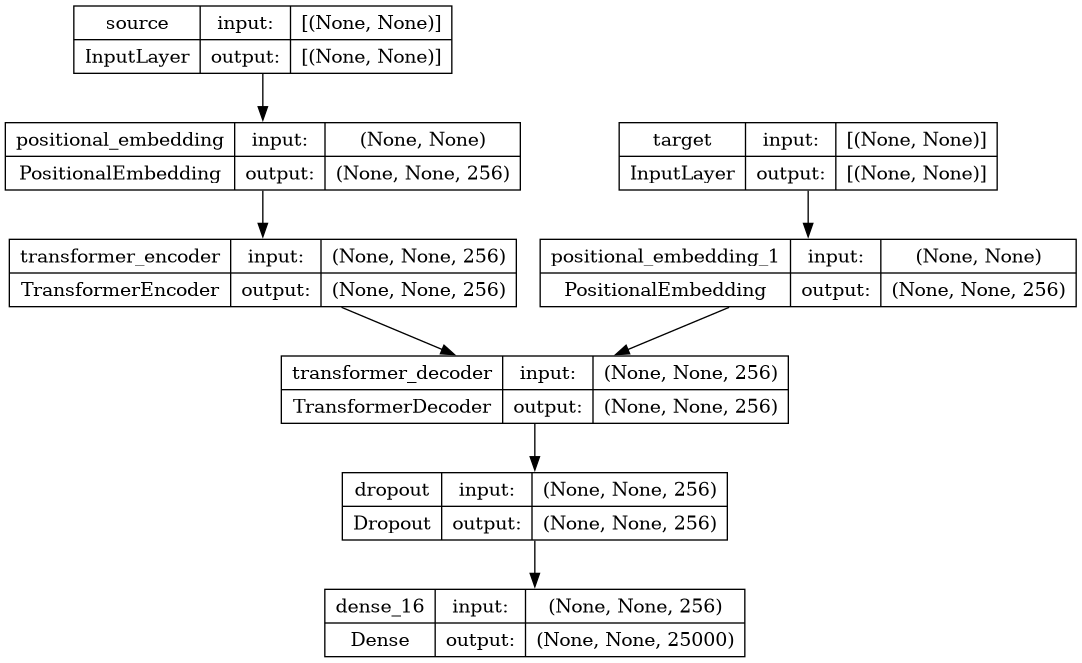

In [23]:
tf.keras.utils.plot_model(transformer, show_shapes=True, show_layer_names=True)

**<a id="12"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Training the Transformer </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [24]:
transformer.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

EPOCHS = 50
checkpoint_filepath = '/tmp/checkpoint/'
callbacks_list = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.1,
        patience=3,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_filepath,
        save_weights_only=True,
        monitor='val_loss',
        save_best_only=True
    ),
]
    
hist= transformer.fit(train_ds, 
                epochs=EPOCHS, 
                callbacks=callbacks_list,
                validation_data=val_ds)

transformer.load_weights(checkpoint_filepath)

Epoch 1/50


I0000 00:00:1710159547.055152      68 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


355/355 [==============================] - 101s 257ms/step - loss: 1.1758 - accuracy: 0.8598 - val_loss: 0.6708 - val_accuracy: 0.8851 - lr: 0.0010
Epoch 2/50
355/355 [==============================] - 87s 244ms/step - loss: 0.6174 - accuracy: 0.8902 - val_loss: 0.5500 - val_accuracy: 0.8979 - lr: 0.0010
Epoch 3/50
355/355 [==============================] - 86s 243ms/step - loss: 0.5211 - accuracy: 0.9009 - val_loss: 0.4905 - val_accuracy: 0.9061 - lr: 0.0010
Epoch 4/50
355/355 [==============================] - 86s 243ms/step - loss: 0.4582 - accuracy: 0.9090 - val_loss: 0.4457 - val_accuracy: 0.9137 - lr: 0.0010
Epoch 5/50
355/355 [==============================] - 87s 244ms/step - loss: 0.4007 - accuracy: 0.9180 - val_loss: 0.4097 - val_accuracy: 0.9202 - lr: 0.0010
Epoch 6/50
355/355 [==============================] - 87s 244ms/step - loss: 0.3540 - accuracy: 0.9255 - val_loss: 0.3912 - val_accuracy: 0.9240 - lr: 0.0010
Epoch 7/50
355/355 [==============================] - 87s 245m

In [25]:
transformer.save('/kaggle/working/transformer_model')

**<a id="13"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Evaluation the Transformer </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [26]:
hist_=pd.DataFrame(hist.history)
hist_

,loss,accuracy,val_loss,val_accuracy,lr
0,1.175787,0.859844,0.670762,0.885099,1.000000e-03
1,0.617448,0.890232,0.550038,0.897889,1.000000e-03
2,0.521089,0.900908,0.490505,0.906085,1.000000e-03
3,0.458160,0.909024,0.445669,0.913704,1.000000e-03
4,0.400688,0.918011,0.409691,0.920175,1.000000e-03
5,0.354015,0.925481,0.391163,0.924046,1.000000e-03
6,0.316971,0.931624,0.379426,0.927476,1.000000e-03
7,0.286478,0.936685,0.377948,0.928994,1.000000e-03
8,0.260370,0.941284,0.377053,0.930008,1.000000e-03
9,0.238110,0.945311,0.379526,0.931343,1.000000e-03


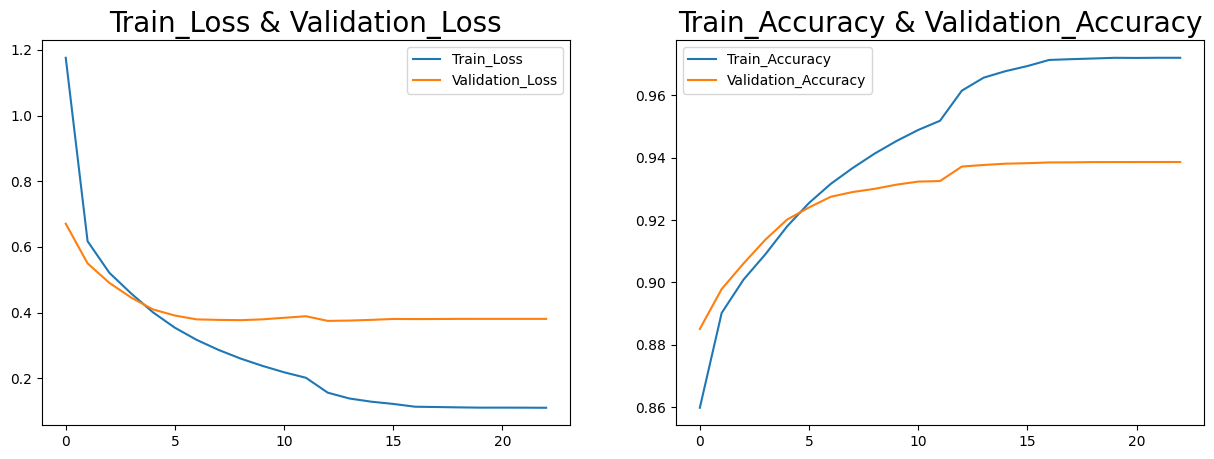

In [27]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(hist_['loss'],label='Train_Loss')
plt.plot(hist_['val_loss'],label='Validation_Loss')
plt.title('Train_Loss & Validation_Loss',fontsize=20)
plt.legend()
plt.subplot(1,2,2)
plt.plot(hist_['accuracy'],label='Train_Accuracy')
plt.plot(hist_['val_accuracy'],label='Validation_Accuracy')
plt.title('Train_Accuracy & Validation_Accuracy',fontsize=20)
plt.legend()
plt.show()

In [28]:
score,acc = transformer.evaluate(test_ds)
print('Test Loss =', score)
print('Test Accuracy =', acc)

20/20 [==============================] - 3s 125ms/step - loss: 0.3853 - accuracy: 0.9362
Test Loss = 0.385326087474823
Test Accuracy = 0.9361587166786194


**<a id="14"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Saving Tokenizer for Source and Target </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [29]:
vectorize_layer_model = tf.keras.models.Sequential()
vectorize_layer_model.add(tf.keras.Input(shape=(1,), dtype=tf.string))
vectorize_layer_model.add(source_vectorization)
vectorize_layer_model.summary()
vectorize_layer_model.save("/kaggle/working/input_model", save_format="tf")

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization (TextVe  (None, 200)               0         
 ctorization)                                                    
                                                                 
Total params: 0 (0.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [30]:
model=tf.keras.models.Sequential([
    tf.keras.Input(shape=(1,),dtype=tf.string),
    target_vectorization
])
model.summary()
model.save("/kaggle/working/target_model_output",save_format="tf")

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization_1 (Text  (None, 201)               0         
 Vectorization)                                                  
                                                                 
Total params: 0 (0.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


**<a id="15"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Testing the Transformer </p>
<a class="btn" href="#home">Tabel of Contents</a>

In [31]:
model=tf.keras.models.load_model('/kaggle/working/transformer_model')

Let's translate a few random test sentences with our newly-trained Transformer.

In [32]:
target_vocab = target_vectorization.get_vocabulary()
target_index_lookup = dict(zip(range(len(target_vocab)), target_vocab))
max_decoded_sentence_length = 200

def decode_sequence(input_sentence):
    tokenized_input_sentence = source_vectorization([input_sentence])
    decoded_sentence = "[start]"
    for i in range(max_decoded_sentence_length):
        tokenized_target_sentence = target_vectorization(
            [decoded_sentence])[:, :-1]
        predictions = model(
            [tokenized_input_sentence, tokenized_target_sentence])
        sampled_token_index = np.argmax(predictions[0, i, :])
        sampled_token = target_index_lookup[sampled_token_index]
        decoded_sentence += " " + sampled_token
        if sampled_token == "[end]":
            break
    return decoded_sentence

for i in range(50):
    random_index = np.random.randint(0, len(test_df))
    input_sentence = test_df["source"].iloc[random_index]
    print(input_sentence)
    print(decode_sequence(input_sentence))
    print()

How can caregivers address feelings of frustration or guilt associated with managing mind wandering in Alzheimer's patients?
[start] feelings of guilt or shame can be caregivers with others facing challenges with alzheimers patients and their caregivers should prioritize selfcare seek support and support from healthcare providers and prioritize selfcare to manage feelings and halt the emotional progression                                                                                                                                                                 

Can Alzheimer's disease affect a person's ability to recognize the needs of others?
[start] alzheimers disease can impair the ability to recognize familiar faces or places due to challenges in memory communication social interactions and social interactions                                                                                                                                                                           

**<a id="16"></a>
# <p style="background-image: url(https://i.postimg.cc/K87ByXmr/stage5.jpg);font-family:camtasia;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px">Reference </p>
<a class="btn" href="#home">Tabel of Contents</a>

- https://arxiv.org/abs/1706.03762

- https://www.tensorflow.org/text/tutorials/transformer

- https://github.com/openai/gpt-2/blob/master/src/model.py

- https://github.com/karpathy/minGPT/blob/master/mingpt/model.py

- https://livebook.manning.com/book/deep-learning-with-python-second-edition/chapter-11

    - https://github.com/fchollet/deep-learning-with-python-notebooks/blob/master/chapter11_part03_transformer.ipynb

    - https://github.com/fchollet/deep-learning-with-python-notebooks/blob/master/chapter11_part04_sequence-to-sequence-learning.ipynb

- https://www.oreilly.com/library/view/natural-language-processing/9781098136789/ch03.html

    - https://github.com/nlp-with-transformers/notebooks/blob/main/03_transformer-anatomy.ipynb